In [1]:
!pip install transformers torch pillow

In [2]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the model and processor
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

print(f"Model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded on cuda


Image successfully loaded from /content/Image.jpg!


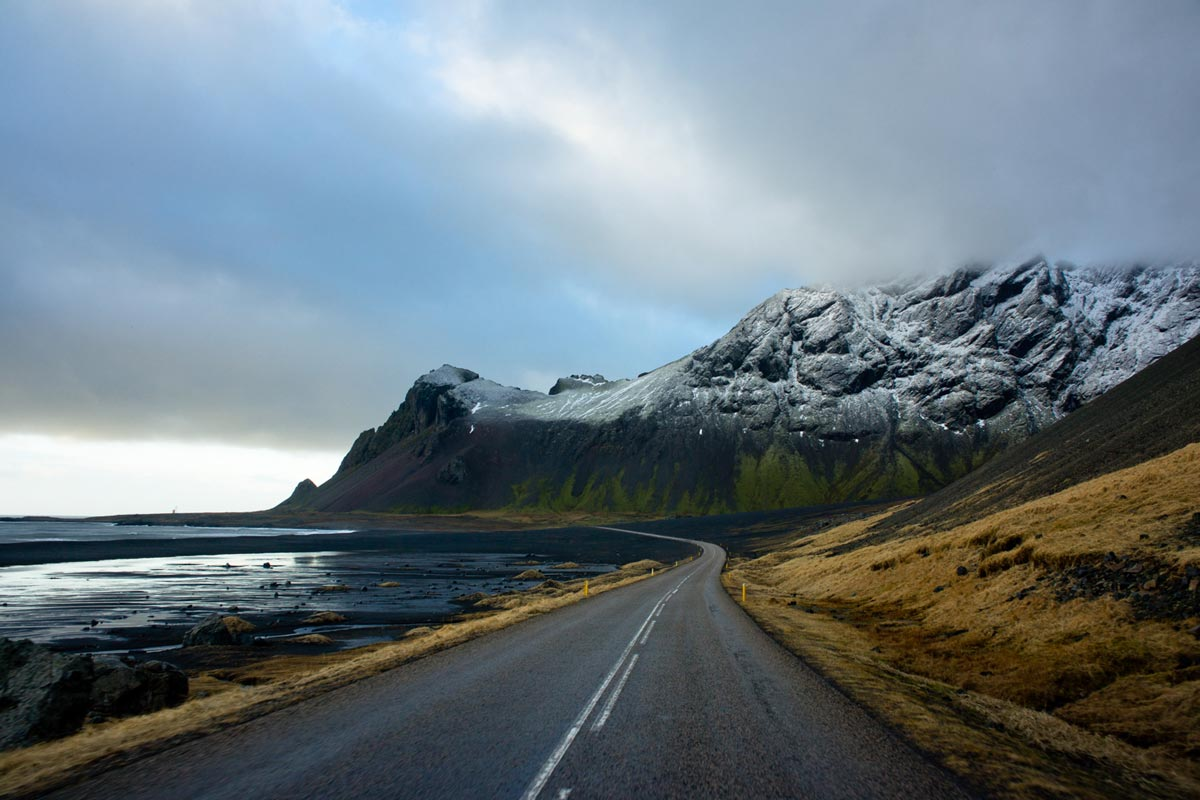

In [23]:
from PIL import Image

# 1. Load a local image file
image_path = "/content/Image.jpg"

try:
    image = Image.open(image_path).convert("RGB")
    print(f"Image successfully loaded from {image_path}!")
    display(image)
except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}")
except Exception as e:
    print(f"An error occurred while loading the image: {e}")

# 4. Define "candidate" captions
candidate_captions = [
    "a photo of a lush green forest with a river",
    "a bustling city street at night with neon lights",
    "a close up of a delicious chocolate cake",
    "a snowy mountain peak under a blue sky",
    "a portrait of a golden retriever dog"
]

In [24]:
# Process inputs
inputs = processor(
    text=candidate_captions,
    images=image,
    return_tensors="pt",
    padding=True
).to(device)

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Get the similarity scores (logits)
# logits_per_image is the similarity between the image and each text
probs = outputs.logits_per_image.softmax(dim=1)

# Find the index of the highest probability
best_idx = probs.argmax().item()

print(f"Top Caption: {candidate_captions[best_idx]}")
print(f"Confidence: {probs[0][best_idx].item():.2%}")

Top Caption: a snowy mountain peak under a blue sky
Confidence: 97.89%
